In [1]:
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from unet import unet_network
from attention_unet import attention_unet

from plot_functions import plot_results

2024-04-29 19:50:24.670778: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-29 19:50:24.670843: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-29 19:50:24.673640: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-04-29 19:50:24.686307: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-04-29 19:50:25.565651: W tensorflow/compiler/tf2

In [2]:
tf.__version__

'2.15.0'

In [3]:
porosity = np.load('data_decatur/processed/test/porosity.npy')
impedance = np.load('data_decatur/processed/test/impedance.npy')

In [4]:
impedance.shape

(2437, 32, 32)

In [5]:
model = unet_network()
#input_shape = (32, 32, 1)
#model = attention_unet(input_shape)
#print(model.summary())

2024-04-29 19:50:27.672081: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-29 19:50:27.731470: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-29 19:50:27.731523: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-29 19:50:27.734526: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2024-04-29 19:50:27.734658: I external/local_xla/xla/stream_executor

In [6]:
model.load_weights('saved_model/best_model_unet.keras')

/home/nicolas/datascience/tesismaestria/.tesisenv/lib/python3.10/site-packages/keras/src/initializers/__init__.py:144: UserWarning: The `keras.initializers.serialize()` API should only be used for objects of type `keras.initializers.Initializer`. Found an instance of type <class 'tensorflow.python.ops.init_ops_v2.RandomNormal'>, which may lead to improper serialization.
  warnings.warn(


In [7]:
impedance = np.expand_dims(impedance, -1)

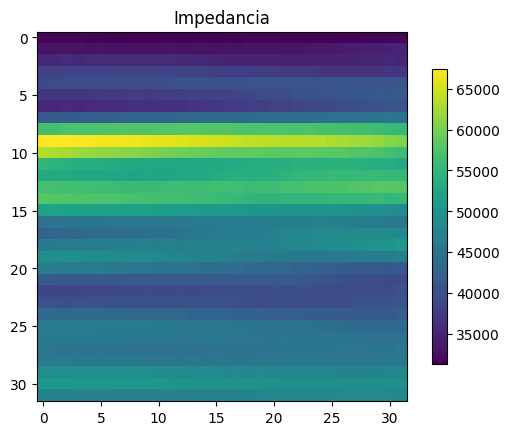

In [8]:
fig, ax = plt.subplots(1,1)

im = ax.imshow(impedance[10,...])
ax.set_title('Impedancia')
fig.colorbar(im, ax=ax, shrink=0.8)


# Pre-Procesamiento Impedancia

In [9]:
max_X = np.max(impedance)
min_X = np.min(impedance)

impedance_norm = (impedance - min_X)/(max_X - min_X)

In [10]:
porosity = np.expand_dims(porosity, -1)

In [11]:
porosity[porosity<0] = 0.0001

# Predicción

In [12]:
porosity_modeled = model.predict(impedance_norm)

2024-04-29 19:50:31.384217: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-04-29 19:50:31.577879: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


 6/77 [=>............................] - ETA: 1s

2024-04-29 19:50:32.957217: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


77/77 [==============================] - 5s 39ms/step


El error es 4.2227578095116203e-07
Las dimensiones del Y predict es (2437, 32, 32, 1)
Las dimensiones del Y normal es (2437, 32, 32, 1)


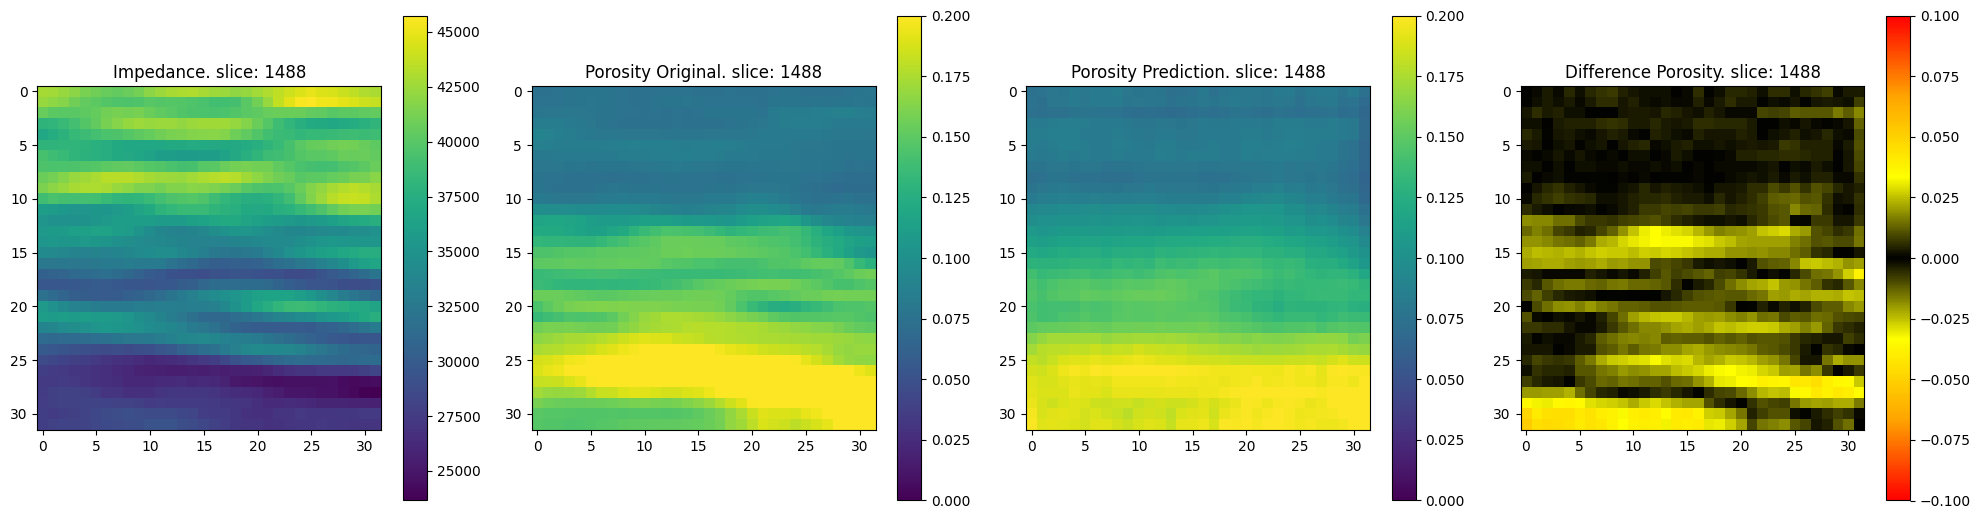

In [22]:
plot_results(impedance, porosity_modeled, porosity, False)